# Controlled A/B Testing Demonstration — Synthetic Experiment

> **This notebook uses SYNTHETIC data generated below with a fixed random seed.** It is not a real experiment, not
> company data and not a claim of production A/B testing experience. The campaign dataset in this repository is
> observational (nobody randomised which campaigns ran), so it cannot be used for a controlled experiment.
> The purpose is to demonstrate the end-to-end method an analyst follows.

Statistics helpers are reused from `src/experimentation/stats.py` (unit-tested in `tests/test_experimentation.py`).

In [1]:
import sys
from pathlib import Path
ROOT = Path("..").resolve(); sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, confint_proportions_2indep

from src.experimentation import stats as S

sns.set_theme(style="whitegrid")
SEED = 2026

## 1. Business question and hypothesis
**Question:** Does showing *"Frequently bought together"* recommendations on the cart page increase purchases?

* **H0:** checkout conversion rate is the same with and without the recommendation widget.
* **H1:** conversion rate differs (two-sided test, so we can also detect harm).

## 2. Metrics (fixed before launch)
| Role | Metric | Unit |
|---|---|---|
| **Primary** | conversion rate = users who purchase / users assigned | user |
| **Secondary** | revenue per user (includes zeros for non-buyers) | user |
| **Guardrail** | refund rate among buyers | buyer |

The unit of randomisation (user) equals the unit of analysis, so standard tests apply.

## 3. Design: groups, MDE, sample size, duration
* **Control (A):** current cart page. **Treatment (B):** cart page with the widget. 50/50 split.
* **Baseline conversion:** 3.5% (assumed for the synthetic scenario).
* **Minimum detectable effect (MDE):** +8% relative (3.50% → 3.78%). This is the smallest lift worth the
  engineering and maintenance cost — a *business* decision made before the test.
* **α = 0.05** (false-positive rate), **power = 0.80** (chance of detecting a true +8% lift).

In [2]:
P0, MDE, ALPHA, POWER = 0.035, 0.08, 0.05, 0.80
n_per_arm = S.sample_size_proportion(P0, MDE, ALPHA, POWER)
DAILY_USERS = 12_000
days = S.duration_days(n_per_arm, arms=2, daily_eligible_users=DAILY_USERS)
print(f"required users per arm: {n_per_arm:,}")
print(f"duration at {DAILY_USERS:,} eligible users/day: {days} days (rounded up to whole weeks)")

# cross-check with statsmodels
es = proportion_effectsize(P0 * (1 + MDE), P0)
print(f"statsmodels check: {NormalIndPower().solve_power(es, alpha=ALPHA, power=POWER):,.0f} users per arm")

required users per arm: 70,229
duration at 12,000 eligible users/day: 14 days (rounded up to whole weeks)
statsmodels check: 70,204 users per arm


### Statistical power curve
Power is the probability of detecting the effect *if it exists*. With too few users, a real +8% lift is usually missed
(an under-powered test), and the lifts that do reach significance are exaggerated.

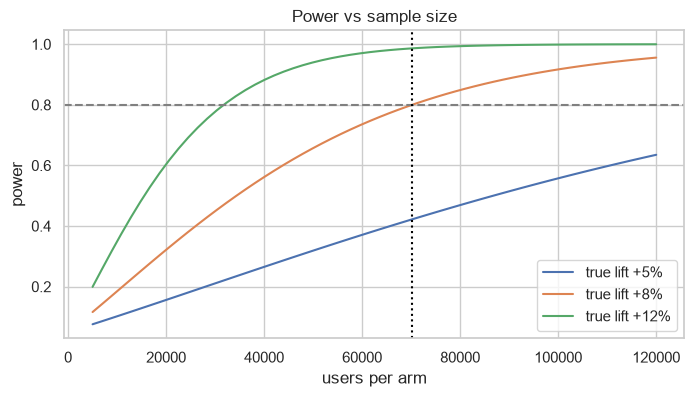

In [3]:
ns = np.linspace(5_000, 120_000, 60)
plt.figure(figsize=(8, 4))
for lift in [0.05, 0.08, 0.12]:
    es_l = proportion_effectsize(P0 * (1 + lift), P0)
    plt.plot(ns, NormalIndPower().power(es_l, nobs1=ns, alpha=ALPHA), label=f"true lift +{lift:.0%}")
plt.axhline(0.8, ls="--", c="grey"); plt.axvline(n_per_arm, ls=":", c="black")
plt.xlabel("users per arm"); plt.ylabel("power"); plt.title("Power vs sample size"); plt.legend(); plt.show()

## 4. Randomisation and synthetic data
Users are randomly assigned 50/50. The simulation bakes in a **true lift of +10%** on conversion and no effect on
order value — the analyst below does not use this number; it only lets us check the method recovers the truth.
A pre-period spend column is also generated for CUPED variance reduction.

In [4]:
rng = np.random.default_rng(SEED)
N = 2 * n_per_arm
TRUE_LIFT = 0.10
segments = np.array(["New visitor", "Returning", "Loyalty member"])
df = pd.DataFrame({
    "user_id": np.arange(N),
    "variant": np.where(rng.random(N) < 0.5, "treatment", "control"),
    "segment": rng.choice(segments, N, p=[0.5, 0.35, 0.15]),
    "device": rng.choice(["mobile", "desktop"], N, p=[0.7, 0.3]),
})
seg_mult = df["segment"].map({"New visitor": 0.7, "Returning": 1.2, "Loyalty member": 1.8}).to_numpy()
df["pre_period_spend"] = rng.gamma(1.5, 300, N) * seg_mult
p = P0 * seg_mult / seg_mult.mean() * np.where(df["variant"] == "treatment", 1 + TRUE_LIFT, 1.0)
df["converted"] = (rng.random(N) < p).astype(int)
order_value = rng.lognormal(np.log(480), 0.45, N) * (1 + df["pre_period_spend"] / 3000)
df["revenue"] = np.where(df["converted"] == 1, order_value, 0.0)
df["refunded"] = ((df["converted"] == 1) & (rng.random(N) < 0.06)).astype(int)
df["is_synthetic"] = 1
df.head()

,user_id,variant,segment,device,pre_period_spend,converted,revenue,refunded,is_synthetic
0,0,treatment,New visitor,mobile,1083.655813,0,0.0,0,1
1,1,control,New visitor,mobile,419.914567,0,0.0,0,1
2,2,treatment,Loyalty member,mobile,242.579638,0,0.0,0,1
3,3,treatment,New visitor,mobile,372.033137,0,0.0,0,1
4,4,treatment,New visitor,mobile,362.245263,0,0.0,0,1


## 5. Data validation before reading any result
### Sample Ratio Mismatch (SRM)
If a 50/50 test does not come out close to 50/50, assignment or logging is broken (bots filtered in one arm,
a redirect dropping users, etc.). **With SRM, no metric can be trusted** — stop and debug. A strict threshold
(p < 0.001) is used because this check runs on every test.

In [5]:
counts = df["variant"].value_counts().to_dict()
srm = S.srm_check(counts, {"control": 0.5, "treatment": 0.5})
print(counts); print(srm)
assert df["user_id"].is_unique, "duplicate users"
assert df.groupby("user_id")["variant"].nunique().max() == 1, "user in both arms"
print("validation passed: unique users, single assignment, no SRM" if not srm["srm_detected"] else "SRM DETECTED - stop")

{'treatment': 70629, 'control': 69829}
{'chi2': 4.556522234404591, 'p_value': 0.03279360028434298, 'srm_detected': False, 'observed_split': {'treatment': 0.5028, 'control': 0.4972}}
validation passed: unique users, single assignment, no SRM


## 6. Primary metric: statistical test, confidence interval, uplift

In [6]:
g = df.groupby("variant").agg(users=("user_id", "count"), buyers=("converted", "sum"))
g["conversion_rate"] = g.buyers / g.users
xc, nc = int(g.loc["control", "buyers"]), int(g.loc["control", "users"])
xt, nt = int(g.loc["treatment", "buyers"]), int(g.loc["treatment", "users"])
r = S.proportion_test(xc, nc, xt, nt)
abs_lo, abs_hi = confint_proportions_2indep(xt, nt, xc, nc, method="wald")
display(g)
print(f"absolute uplift : {r.abs_diff*100:+.3f} pp   (95% CI {abs_lo*100:+.3f} to {abs_hi*100:+.3f} pp)")
print(f"relative uplift : {r.rel_lift:+.2%}       (95% CI {r.ci_low:+.2%} to {r.ci_high:+.2%})")
print(f"two-sided p-value: {r.p_value:.2e}")

,users,buyers,conversion_rate
variant,,,
control,69829,2432,0.034828
treatment,70629,2592,0.036699


absolute uplift : +0.187 pp   (95% CI -0.007 to +0.381 pp)
relative uplift : +5.37%       (95% CI -0.20% to +11.26%)
two-sided p-value: 5.91e-02


### Statistical vs practical significance
* **Statistical significance** answers: *is the difference unlikely to be zero?* (p < α, CI excludes 0).
* **Practical (business) significance** answers: *is the difference big enough to matter?* — compare the CI with the
  MDE agreed before the test, and translate it into money.

A huge test can make a 0.5% lift "significant" yet worthless; a small test can miss a valuable lift. The decision uses both.

In [7]:
aov = df.loc[df.converted == 1, "revenue"].mean()
monthly_users = DAILY_USERS * 30
extra_orders = monthly_users * r.abs_diff
print(f"CI lower bound {r.ci_low:+.2%} vs MDE {MDE:+.0%} -> "
      + ("lift is at least the MDE with 95% confidence" if r.ci_low >= MDE else
         "lift is significant but could be smaller than the MDE" if r.ci_low > 0 else "not significant"))
print(f"illustrative impact: {extra_orders:,.0f} extra orders/month x AOV {aov:,.0f} = {extra_orders*aov:,.0f} revenue/month "
      f"(range {monthly_users*abs_lo*aov:,.0f} to {monthly_users*abs_hi*aov:,.0f})")

CI lower bound -0.20% vs MDE +8% -> not significant
illustrative impact: 674 extra orders/month x AOV 622 = 419,009 revenue/month (range -15,968 to 853,986)


### Power, after the fact
"Observed power" computed from the observed effect adds no information. The useful question is: *given the sample we
actually collected, what is the smallest lift we could reliably detect?*

In [8]:
print(f"achieved MDE at n={min(nc, nt):,}/arm: {S.mde_for_sample(P0, min(nc, nt)):+.2%} relative")

achieved MDE at n=69,829/arm: +7.87% relative


## 7. Secondary metric: revenue per user (Welch t-test, with and without CUPED)

In [9]:
c = df[df.variant == "control"]; t = df[df.variant == "treatment"]
raw = S.mean_test(c.revenue.to_numpy(), t.revenue.to_numpy())
adj = df["revenue"].to_numpy()
adj = S.cuped(adj, df["pre_period_spend"].to_numpy())
df["revenue_cuped"] = adj
cup = S.mean_test(df.loc[df.variant == "control", "revenue_cuped"].to_numpy(),
                  df.loc[df.variant == "treatment", "revenue_cuped"].to_numpy())
pd.DataFrame([{"method": "Welch", "rel_lift": raw.rel_lift, "ci_low": raw.ci_low, "ci_high": raw.ci_high, "p": raw.p_value},
              {"method": "Welch + CUPED", "rel_lift": cup.rel_lift, "ci_low": cup.ci_low, "ci_high": cup.ci_high, "p": cup.p_value}])

,method,rel_lift,ci_low,ci_high,p
0,Welch,0.061949,-0.002574,0.126473,0.052461
1,Welch + CUPED,0.061579,-0.002817,0.125975,0.053457


CUPED subtracts the part of the outcome explained by pre-experiment behaviour. It keeps the estimate unbiased and
shrinks variance by roughly r², where r is the correlation between the covariate and the outcome. The gain is only
as good as the covariate:

In [10]:
rho = np.corrcoef(df["revenue"], df["pre_period_spend"])[0, 1]
print(f"corr(revenue, pre-period spend) = {rho:.3f} -> expected variance reduction ~ {rho**2:.1%}")
print(f"observed variance reduction     = {1 - df.revenue_cuped.var() / df.revenue.var():.1%}")
print("Here the covariate is weak, so CUPED barely narrows the CI. With a strong covariate (e.g. the same metric "
      "measured before the test, r ~ 0.5+) it can cut the required sample by 25% or more.")

corr(revenue, pre-period spend) = 0.057 -> expected variance reduction ~ 0.3%
observed variance reduction     = 0.3%
Here the covariate is weak, so CUPED barely narrows the CI. With a strong covariate (e.g. the same metric measured before the test, r ~ 0.5+) it can cut the required sample by 25% or more.


## 8. Guardrail: refund rate (must not get significantly worse)

In [11]:
b = df[df.converted == 1].groupby("variant").agg(buyers=("user_id", "count"), refunds=("refunded", "sum"))
gr = S.proportion_test(int(b.loc["control", "refunds"]), int(b.loc["control", "buyers"]),
                       int(b.loc["treatment", "refunds"]), int(b.loc["treatment", "buyers"]), metric="refund_rate")
guardrail_ok = not (gr.p_value < ALPHA and gr.rel_lift > 0)
print(f"refund rate {gr.control:.2%} -> {gr.treatment:.2%} (rel {gr.rel_lift:+.1%}, p={gr.p_value:.2f}) ->",
      "OK" if guardrail_ok else "BREACH")

refund rate 5.43% -> 5.29% (rel -2.6%, p=0.82) -> OK


## 9. Segment analysis and multiple testing
Every extra comparison is another chance of a false positive: with 10 independent tests at α = 0.05 the chance of at
least one false "win" is 1 − 0.95¹⁰ ≈ 40%. Segment results are **exploratory**, reported with Holm-adjusted p-values,
and are never used to override the primary decision.

In [12]:
rows = []
for col in ["segment", "device"]:
    for val, d in df.groupby(col):
        dc, dt = d[d.variant == "control"], d[d.variant == "treatment"]
        rr = S.proportion_test(int(dc.converted.sum()), len(dc), int(dt.converted.sum()), len(dt))
        rows.append({"cut": f"{col}={val}", "users": len(d), "cvr_control": rr.control, "cvr_treatment": rr.treatment,
                     "rel_lift": rr.rel_lift, "ci_low": rr.ci_low, "ci_high": rr.ci_high, "p_raw": rr.p_value})
seg = pd.DataFrame(rows)
seg["p_holm"] = S.holm(seg["p_raw"].tolist())
seg["significant_after_holm"] = seg["p_holm"] < ALPHA
seg

,cut,users,cvr_control,cvr_treatment,rel_lift,ci_low,ci_high,p_raw,p_holm,significant_after_holm
0,segment=Loyalty member,20948,0.063157,0.063912,0.011960,-0.087986,0.122860,0.822686,0.822686,False
1,segment=New visitor,70488,0.023282,0.025401,0.091030,-0.006430,0.198050,0.067930,0.339652,False
2,segment=Returning,49022,0.039428,0.041216,0.045363,-0.041169,0.139704,0.314210,0.714161,False
3,device=desktop,41988,0.033563,0.035669,0.062739,-0.039451,0.175801,0.238054,0.714161,False
4,device=mobile,98470,0.035362,0.037142,0.050333,-0.015207,0.120234,0.135181,0.540722,False


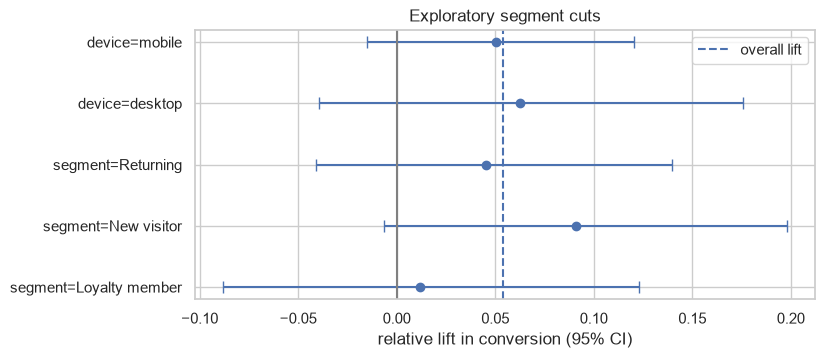

In [13]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.errorbar(seg.rel_lift, seg.cut, xerr=[seg.rel_lift - seg.ci_low, seg.ci_high - seg.rel_lift], fmt="o", capsize=4)
ax.axvline(0, c="grey"); ax.axvline(r.rel_lift, ls="--", label="overall lift"); ax.legend()
ax.set_xlabel("relative lift in conversion (95% CI)"); ax.set_title("Exploratory segment cuts"); plt.show()

## 10. Why peeking breaks the test
Checking the p-value every day and stopping at the first p < 0.05 inflates the false-positive rate. Below: 2,000
simulated **A/A tests** (no true difference), each checked at 10 interim looks.

In [14]:
sim_rng = np.random.default_rng(7)
n_sims, looks, n_look = 2000, 10, 4000
a = sim_rng.binomial(n_look, P0, size=(n_sims, looks)).cumsum(1)
bb = sim_rng.binomial(n_look, P0, size=(n_sims, looks)).cumsum(1)
n_cum = n_look * np.arange(1, looks + 1)
pa, pb = a / n_cum, bb / n_cum
pool = (a + bb) / (2 * n_cum)
z = (pb - pa) / np.sqrt(pool * (1 - pool) * 2 / n_cum)
sig = np.abs(z) > stats.norm.ppf(1 - ALPHA / 2)
print(f"false-positive rate, single look at the end : {sig[:, -1].mean():.1%}")
print(f"false-positive rate, stop at first p<0.05   : {sig.any(1).mean():.1%}")

false-positive rate, single look at the end : 5.0%
false-positive rate, stop at first p<0.05   : 21.4%


Fixes: decide the sample size up front and look once, or use a method designed for monitoring
(group-sequential boundaries, alpha spending, always-valid / Bayesian approaches).

## 11. Observational analysis is not an experiment
In the campaign data (notebook 01), campaigns could be compared by type or channel — but those campaigns were not
randomly assigned. Differences can come from budget, season, audience or brand (**confounding**), and aggregating
across groups can even reverse a relationship (**Simpson's paradox**). Randomisation balances all of these, measured
and unmeasured, which is why only the controlled test supports a causal claim. Observational patterns are useful for
*generating* hypotheses to test.

## 12. Decision

In [15]:
if srm["srm_detected"]:
    decision = "INVALID - fix assignment and rerun"
elif not guardrail_ok:
    decision = "DO NOT SHIP - guardrail breached"
elif r.p_value < ALPHA and r.ci_low >= MDE:
    decision = "SHIP"
elif r.p_value < ALPHA and r.ci_low > 0:
    decision = "SHIP WITH MONITORING - significant, but lift may be below the MDE"
elif r.ci_high < MDE:
    decision = "DO NOT SHIP - CI rules out a lift as large as the MDE"
else:
    decision = "INCONCLUSIVE - planned sample reached; do not ship on this evidence"
summary = pd.Series({
    "data": "SYNTHETIC (seeded simulation)",
    "users per arm (planned)": f"{n_per_arm:,}",
    "SRM p-value": f"{srm['p_value']:.3f}",
    "conversion lift (rel, 95% CI)": f"{r.rel_lift:+.2%} [{r.ci_low:+.2%}, {r.ci_high:+.2%}]",
    "p-value": f"{r.p_value:.1e}",
    "revenue/user lift (CUPED)": f"{cup.rel_lift:+.2%} [{cup.ci_low:+.2%}, {cup.ci_high:+.2%}]",
    "refund guardrail": "OK" if guardrail_ok else "BREACH",
    "segments significant after Holm": int(seg.significant_after_holm.sum()),
    "decision": decision,
})
summary.to_frame("result")

,result
data,SYNTHETIC (seeded simulation)
users per arm (planned),"70,229"
SRM p-value,0.033
"conversion lift (rel, 95% CI)","+5.37% [-0.20%, +11.26%]"
p-value,5.9e-02
revenue/user lift (CUPED),"+6.16% [-0.28%, +12.60%]"
refund guardrail,OK
segments significant after Holm,0
decision,INCONCLUSIVE - planned sample reached; do not ...


## 13. Why did the test miss? (only possible because the data is simulated)
The simulation contains a true +10% lift, yet this run is not significant. That is a **Type II error**, and a planned
power of 80% at the +8% MDE means it *will* happen in some fraction of real tests. Re-running the identical experiment
1,000 times shows how often a correctly designed test detects the true effect:

In [16]:
rep = np.random.default_rng(11)
reps = 1000
xc_r = rep.binomial(n_per_arm, P0, reps)
xt_r = rep.binomial(n_per_arm, P0 * (1 + TRUE_LIFT), reps)
pvals = np.array([S.proportion_test(int(a), n_per_arm, int(b), n_per_arm).p_value for a, b in zip(xc_r, xt_r)])
theory = NormalIndPower().power(proportion_effectsize(P0 * (1 + TRUE_LIFT), P0), nobs1=n_per_arm, alpha=ALPHA)
print(f"share of repeats reaching p < 0.05: {(pvals < ALPHA).mean():.1%}  (theoretical power for +10%: {theory:.1%})")
print("This run landed in the unlucky minority. The right response is NOT to keep the test running until it turns "
      "significant (that is peeking, section 10).")

share of repeats reaching p < 0.05: 94.0%  (theoretical power for +10%: 93.7%)
This run landed in the unlucky minority. The right response is NOT to keep the test running until it turns significant (that is peeking, section 10).


### Recommendation (synthetic scenario)
* **Decision: do not ship on this evidence.** The planned sample was reached, SRM and the refund guardrail passed, but
  the 95% CI on conversion lift (about −0.2% to +11%) still includes zero.
* The CI also does not rule out a lift above the +8% MDE, so the idea is not disproven. If the upside justifies it,
  run a **new, pre-registered follow-up test** (fresh sample, same metrics) rather than extending this one.
* No segment is significant after Holm correction, so there is no basis for a segment-only launch.
* Statistical significance ≠ business significance: even a significant result would only ship if its CI cleared the
  MDE that makes the feature worth building.

Related material: `docs/ab_testing_guide.md` (workflow and pitfalls) and `src/experimentation/` (pre-registered
decision framework applied to four further simulated tests, `reports/experiments/`).